In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("intro2Streamlit.ipynb")

## Lecture Section

In this lecture, we will cover the basics of using Streamlit. Streamlit is an open-source Ptyhon framework that allows you to create interactive apps. You cann create an application with a Python notebook. Instead, you will copy all the code from this notebook into a .py file. When you publish your app, you'll take the link and submit that as the answer in the assignment section!

We will cover:
* Creating the App
* Displaying Text
* Getting User Input
* Displaying Data with Pandas
* Charts & Visualization
* Layout
* Session State
* Cache
* Upload & Download
* Finishing Touches...
* Deployment

ChatGPT is very good at making basic Streamlit applications but striggles to add in more advanced interaction. I suggest starting with a prompt and fixing bugs/adding interactivity, after walking through this tutorial.

### Creating the App

Create a .py file called `stream.py`. When you want to run your app, you will run `streamlit run stream.py`. Make sure to run `pip install streamlit` first! You can run your app at any point between sections and see what you've added - however, if you run it now, it will automatically update with your changes as you code.

In [2]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np

In [3]:
st.title("Hello, Streamlit!")
st.write("Welcome to your first Streamlit app.")

2026-04-21 19:50:09.403 
  command:

    streamlit run C:\Users\marcu\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


### Displaying Text

The next section of code gives you options for displaying text. The last one, `.write()`, is kind-of like Python's `print()` statement. It can display a lot of different things.

In [4]:
st.title("This is a Title")
st.header("This is a Header")
st.subheader("This is a Subheader")
st.text("Plain text goes here.")
st.markdown("**Bold**, *italic*, and `code` with Markdown!")
st.caption("Small caption text.")

st.write("st.write() can display almost anything!")

### Getting User Input

It is easy to get user-input. We can ask for text, show a slider, checkboxes, multi-select boxes, and provide buttons that do something special. To get the data back to us, we just assign the input back to a variable.

In [5]:

# Text input
name = st.text_input("What's your name?")
if name:
    st.write(f"Hello, {name}!")

# Slider
age = st.slider("Select your age", min_value=0, max_value=100, value=25)
st.write(f"You are {age} years old.")

# Checkbox
show_secret = st.checkbox("Show secret message")
if show_secret:
    st.success("You found the secret!")

# Select box
color = st.selectbox("Pick a color", ["Red", "Green", "Blue", "Yellow"])
st.write(f"You chose: {color}")

# Multi-select
fruits = st.multiselect("Pick your favorite fruits", ["Apple", "Banana", "Cherry", "Mango"])
st.write(f"Your favorites: {fruits}")

# Button
if st.button("Click me!"):
    st.balloons()  # Fun celebration effect!

2026-04-21 19:50:09.512 Session state does not function when running a script without `streamlit run`


### Displaying Data with Pandas

We can easily show tables in our app. We have two options: a static, non-interactive table and one that is dynamic. To create a static one, we call `.table()` and for the interactive one we call `.dataframe()`. We can use columns to provide some info about our data, too!

In [6]:
df = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie", "Diana"],
    "Age": [28, 34, 22, 45],
    "Score": [88.5, 92.3, 78.1, 95.0]
})

st.subheader("Static Table")
st.table(df)  # Non-interactive

st.subheader("Interactive DataFrame")
st.dataframe(df, use_container_width=True)  # Sortable, scrollable

# Metric cards
col1, col2, col3 = st.columns(3)
col1.metric("Average Score", f"{df['Score'].mean():.1f}", "+2.3")
col2.metric("Total Students", len(df))
col3.metric("Top Score", f"{df['Score'].max()}")

DeltaGenerator()

### Charts & Visualization

Streamlit has built-in charts we can use, but we can use matplotlib, too. If we use matplotlib, the charts are not interactive or pretty. They're just an image.

Notice that our data is made of random numebrs. Every time we click something on our app, the data changes because the entire file re-reruns, so we grab a new random sample. Keep this in mind if you are collecting user data or intentionally using random numbers.

DeltaGenerator()

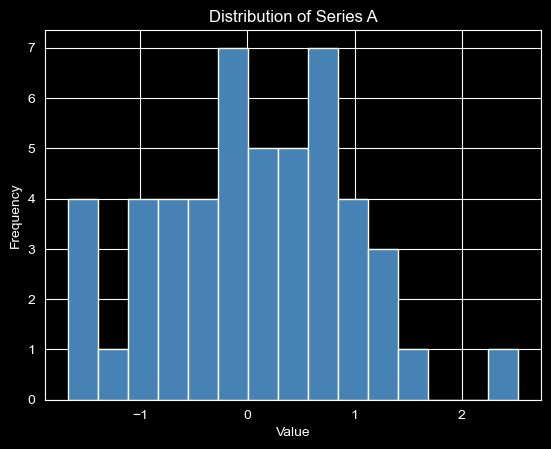

In [7]:
data = pd.DataFrame(
    np.random.randn(50, 3),
    columns=["Series A", "Series B", "Series C"]
)

st.subheader("Built-in Charts")
st.line_chart(data)
st.bar_chart(data.abs().head(10))
st.area_chart(data)

# Matplotlib
st.subheader("Matplotlib Figure")
fig, ax = plt.subplots()
ax.hist(data["Series A"], bins=15, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Series A")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
st.pyplot(fig)

### Layout

There are a lot of layout options in Streamlit.

First, we can create a sidebar. Right now, the sidebar does not do much of anything, but I gave you some ideas for what it *could* do.

Second, we have columns! We already used these above, but I am repeating them here. In the columns, I gave some colored-block options: `info`, `success`, and `warning`. Notice that you can paste emojis and they will show on your application.

Third are tabs. We can switch 'pages' with tabs if they are placed at the top and organized appropriately.

Finally, we have an expander. Hidden content expands and shows when you click it!

In [8]:
# Sidebar
st.sidebar.title("⚙Settings")
theme = st.sidebar.radio("Choose theme", ["Light", "Dark"])
st.write(f"Current theme: **{theme}**")

# Columns
st.subheader("Columns")
col1, col2, col3 = st.columns(3)
with col1:
    st.info("Left")
with col2:
    st.success("Middle")
with col3:
    st.warning("Right")

# Tabs
st.subheader("Tabs")
tab1, tab2, tab3 = st.tabs(["Home", "Data", "ℹAbout"])
with tab1:
    st.write("Welcome to the Home tab!")
with tab2:
    st.write("Data goes here.")
with tab3:
    st.write("About this app.")

# Expander
with st.expander("Click to expand"):
    st.write("Hidden content revealed!")

### Session State

To understand session state, we can make a little `counter` application.`session_state` allows variables to persist when the application re-runs. Your counter should stay the same number when the random numbers aobve reset, for example.

In [9]:
if "count" not in st.session_state:
    st.session_state.count = 0

st.title("Counter App")
st.write(f"Current count: **{st.session_state.count}**")

col1, col2, col3 = st.columns(3)
with col1:
    if st.button("Increment"):
        st.session_state.count += 1
with col2:
    if st.button("Decrement"):
        st.session_state.count -= 1
with col3:
    if st.button("Reset"):
        st.session_state.count = 0

### Cache

Similarly, `@st.cache_data` prevents expensive functions from re-running on every user interaction.

In [10]:
@st.cache_data
def load_data():
    """Simulates a slow data loading operation."""
    time.sleep(2)  # Simulated delay
    return pd.DataFrame({
        "x": range(100),
        "y": [i ** 2 for i in range(100)]
    })

st.title("Caching Demo")
st.write("First load takes 2 seconds. Subsequent loads are instant!")

with st.spinner("Loading data..."):
    df = load_data()

st.success("Data loaded!")
st.line_chart(df.set_index("x"))

2026-04-21 19:50:10.704 No runtime found, using MemoryCacheStorageManager
2026-04-21 19:50:10.704 No runtime found, using MemoryCacheStorageManager


DeltaGenerator()

### Upload & Download

You can let users upload files and then analyze them, and users can download files, too! Upload a .csv file of your choice and watch it work.

In [11]:
st.title("File Upload & Download")

uploaded_file = st.file_uploader("Upload a CSV file", type=["csv"])

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    st.write(f"Loaded **{len(df)} rows** and **{len(df.columns)} columns**.")
    st.dataframe(df.head())

    # Download processed file
    csv = df.to_csv(index=False).encode("utf-8")
    st.download_button(
        label="Download processed CSV",
        data=csv,
        file_name="processed_data.csv",
        mime="text/csv"
    )
else:
    st.info("Please upload a CSV file to get started.")

### Finishing Touches

The last block of code are some finishing touches - you can explore what is down here, or delete it all and do something of your own!

In [12]:
st.set_page_config(page_title="Sales Dashboard", layout="wide")

# Sidebar controls
st.sidebar.title("Sales Dashboard")
num_months = st.sidebar.slider("Months to display", 1, 12, 6)
show_raw = st.sidebar.checkbox("I do NOTHING!")

@st.cache_data
def generate_sales_data(n):
    return pd.DataFrame({
        "Month": [f"Month {i+1}" for i in range(n)],
        "Revenue": np.random.randint(50000, 200000, n),
        "Expenses": np.random.randint(30000, 100000, n),
        "Customers": np.random.randint(100, 500, n)
    })

df = generate_sales_data(num_months)
df["Profit"] = df["Revenue"] - df["Expenses"]

# Title
st.title("Sales Dashboard")
st.markdown(f"Showing data for the last **{num_months} months**.")

# KPI Metrics
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Revenue", f"${df['Revenue'].sum():,}")
col2.metric("Total Expenses", f"${df['Expenses'].sum():,}")
col3.metric("Total Profit", f"${df['Profit'].sum():,}")
col4.metric("Total Customers", f"{df['Customers'].sum():,}")

st.divider()

# Charts in tabs
tab1, tab2 = st.tabs(["Revenue & Expenses", "Customers"])
with tab1:
    st.line_chart(df.set_index("Month")[["Revenue", "Expenses", "Profit"]])
with tab2:
    st.bar_chart(df.set_index("Month")["Customers"])



2026-04-21 19:50:12.788 No runtime found, using MemoryCacheStorageManager
2026-04-21 19:50:12.788 No runtime found, using MemoryCacheStorageManager


### Deployment

---
## 11. Deploying Your App

Deploy for free on **Streamlit Community Cloud**:

1. Push your code to a GitHub repository
2. Go to [share.streamlit.io](https://share.streamlit.io)
3. Connect your GitHub and select your repo
4. Click **Deploy!**

Your app will be live at `https://your-app-name.streamlit.app`.

---

## Quick Reference Cheat Sheet

| Function | Purpose |
|---|---|
| `st.title()`, `st.header()`, `st.subheader()` | Headings |
| `st.write()`, `st.markdown()`, `st.text()` | Display text |
| `st.text_input()`, `st.number_input()` | Text/number input |
| `st.slider()`, `st.select_slider()` | Sliders |
| `st.checkbox()`, `st.radio()`, `st.selectbox()` | Choice widgets |
| `st.button()`, `st.download_button()` | Buttons |
| `st.dataframe()`, `st.table()` | Data display |
| `st.line_chart()`, `st.bar_chart()`, `st.area_chart()` | Built-in charts |
| `st.pyplot()`, `st.plotly_chart()` | Custom charts |
| `st.columns()`, `st.tabs()`, `st.sidebar` | Layout |
| `st.expander()` | Collapsible section |
| `st.session_state` | Persist state across reruns |
| `@st.cache_data` | Cache expensive functions |
| `st.spinner()`, `st.progress()` | Loading indicators |
| `st.success()`, `st.error()`, `st.warning()`, `st.info()` | Alert boxes |
| `st.file_uploader()` | File uploads |
| `st.set_page_config()` | Page title, icon, layout |

---
## Further Resources

- [Official Docs](https://docs.streamlit.io)
- [Streamlit Gallery](https://streamlit.io/gallery) — Community app inspiration
- [Streamlit Community Forum](https://discuss.streamlit.io)
- [Cheat Sheet](https://docs.streamlit.io/library/cheatsheet)

## Assignment Section

<!-- BEGIN QUESTION -->

**Question 1.** Replace 'url-here' with the url of your deployed application after completing the tutorial.

In [13]:
url = ...

<!-- END QUESTION -->

**Question 2.**

Please ignore me :) - I am a free point!

In [14]:
x = 1

In [15]:
grader.check("q2")

q2 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [16]:
grader.check_all()

q2 results: All test cases passed!